# Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
import lightgbm as lgb
import pickle
import re


Semua library yang dibutuhkan diimport di sini. Pandas dan NumPy untuk olah data, Matplotlib dan Seaborn untuk visualisasi, serta scikit-learn, XGBoost, dan LightGBM untuk preprocessing dan modelling.

# Loading Datasets

In [12]:
df = pd.read_csv('data_A (1).csv')


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22440 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21417 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

In [14]:
df.head()

,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


Dataset dibaca dari file CSV, lalu dicek struktur awalnya menggunakan .info() dan .head() untuk memastikan kolom dan tipe data sudah terbaca dengan benar.

# Data Preprocessing

## Drop useless column

In [15]:
df = df.drop('Unnamed: 0', axis=1)

In [16]:
df = df.drop(['ID','Name','SSN'], axis=1)

In [17]:
df = df.drop('Customer_ID', axis=1)

Kolom-kolom yang hanya berfungsi sebagai identifier seperti ID, Name, SSN, dan Customer_ID tidak berguna untuk prediksi, jadi langsung dihapus di sini.

## Clean Numerical Column

In [18]:
def clean_string_to_float(col):
    return pd.to_numeric(df[col].astype(str).str.replace('[^0-9.]', '', regex=True), errors='coerce')

cols_to_fix = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 
               'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

for col in cols_to_fix:
    df[col] = clean_string_to_float(col)

Beberapa kolom numerik ternyata tersimpan sebagai string dengan karakter tidak valid (misal tanda minus atau huruf). Kolom-kolom ini dibersihkan dengan regex agar bisa dikonversi ke tipe float.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     25000 non-null  object 
 1   Age                       25000 non-null  int64  
 2   Occupation                25000 non-null  object 
 3   Annual_Income             25000 non-null  float64
 4   Monthly_Inhand_Salary     21417 non-null  float64
 5   Num_Bank_Accounts         25000 non-null  int64  
 6   Num_Credit_Card           25000 non-null  int64  
 7   Interest_Rate             25000 non-null  int64  
 8   Num_of_Loan               25000 non-null  int64  
 9   Type_of_Loan              22172 non-null  object 
 10  Delay_from_due_date       25000 non-null  int64  
 11  Num_of_Delayed_Payment    23267 non-null  float64
 12  Changed_Credit_Limit      24482 non-null  float64
 13  Num_Credit_Inquiries      24494 non-null  float64
 14  Credit

## Check Duplicated Rows

In [20]:
df.duplicated().sum()

np.int64(0)

Dicek apakah ada baris yang identik di seluruh dataset. Kalau ada, baris duplikat bisa bikin model bias karena data yang sama dihitung lebih dari sekali.

## Check Inconsistent Values

In [21]:

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"--- Unique Values in {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Unique Values in Month ---
Month
April       3173
July        3156
May         3151
March       3139
June        3131
August      3100
February    3087
January     3063
Name: count, dtype: int64


--- Unique Values in Occupation ---
Occupation
_______          1770
Engineer         1650
Lawyer           1618
Architect        1613
Media_Manager    1575
Accountant       1569
Entrepreneur     1559
Developer        1556
Scientist        1553
Teacher          1552
Mechanic         1529
Journalist       1523
Doctor           1519
Manager          1483
Musician         1474
Writer           1457
Name: count, dtype: int64


--- Unique Values in Type_of_Loan ---
Type_of_Loan
Not Specified                                                                                                   355
Credit-Builder Loan                                                                                             319
Debt Consolidation Loan                                                                  

Semua kolom kategorik dicek distribusi nilai uniknya. Tujuannya untuk menemukan nilai-nilai yang tidak valid atau tidak konsisten sebelum dilakukan cleaning.

In [22]:
df['Type_of_Loan'].value_counts()

Type_of_Loan
Not Specified                                                                                                   355
Credit-Builder Loan                                                                                             319
Debt Consolidation Loan                                                                                         318
Personal Loan                                                                                                   317
Mortgage Loan                                                                                                   295
                                                                                                               ... 
Not Specified, Student Loan, Debt Consolidation Loan, and Student Loan                                            1
Personal Loan, Mortgage Loan, Mortgage Loan, Personal Loan, Student Loan, Credit-Builder Loan, and Auto Loan      1
Mortgage Loan, Auto Loan, Debt Consolidation Loan, Debt Con

## Clean Inconsistent Values

In [23]:
df['Occupation'] = df['Occupation'].replace('_______', 'Unknown')


In [24]:
df['Credit_Mix'] = df['Credit_Mix'].apply(lambda x: 'Unknown' if x == '_' or pd.isna(x) else x)

In [ ]:
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('@9#%8'!', 'Unknown')

In [26]:
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', 'Unknown')

Nilai-nilai yang tidak valid seperti `_______`, `!@9#%8`, dan `NM` diganti dengan `Unknown`. Ini penting supaya kolom kategorik punya label yang bersih dan bisa diproses encoder.

## Multi-Label Binarization for  Type_of_Loan Column

In [27]:

df['Type_of_Loan_Clean'] = df['Type_of_Loan'].str.replace('and ', '', regex=False).str.split(', ')

all_types = []
for row in df['Type_of_Loan_Clean'].dropna():
    all_types.extend([item.strip() for item in row])

unique_loan_types = set(all_types)
print(f"Type of Loan: {unique_loan_types}")

Type of Loan: {'Auto Loan', 'Credit-Builder Loan', 'Personal Loan', 'Home Equity Loan', 'Student Loan', 'Debt Consolidation Loan', 'Not Specified', 'Mortgage Loan', 'Payday Loan'}


In [28]:
unique_loan_types.discard('Not Specified')
unique_loan_types.discard('')

for loan in unique_loan_types:
    col_name = f"Loan_{loan.replace(' ', '_').replace('-', '_')}"
    df[col_name] = df['Type_of_Loan'].fillna('').apply(lambda x: 1 if loan in x else 0)

print(df[[col for col in df.columns if col.startswith('Loan_')]].head())

   Loan_Auto_Loan  Loan_Credit_Builder_Loan  Loan_Personal_Loan  \
0               0                         0                   0   
1               0                         0                   0   
2               0                         1                   0   
3               0                         0                   1   
4               1                         0                   0   

   Loan_Home_Equity_Loan  Loan_Student_Loan  Loan_Debt_Consolidation_Loan  \
0                      0                  1                             1   
1                      1                  0                             1   
2                      0                  0                             1   
3                      0                  0                             0   
4                      1                  0                             0   

   Loan_Mortgage_Loan  Loan_Payday_Loan  
0                   0                 0  
1                   1                 0  
2       

In [29]:
df = df.drop('Type_of_Loan', axis = 1)

In [30]:
df = df.drop('Type_of_Loan_Clean', axis=1)

In [31]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Monthly_Balance,Credit_Score,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Student_Loan,Loan_Debt_Consolidation_Loan,Loan_Mortgage_Loan,Loan_Payday_Loan
0,March,8466,Unknown,100433.58,8074.465000,1,5,10,2,13,...,229.212547,Standard,0,0,0,0,1,1,0,0
1,August,25,Developer,33119.82,3024.985000,10,5,32,5,50,...,370.607498,Poor,0,0,0,1,0,1,1,0
2,April,44,Unknown,44822.21,3555.184167,1,4,2,4,14,...,243.999834,Standard,0,1,0,0,0,1,0,1
3,June,29,Musician,142081.48,11771.123333,6,6,15,3,29,...,862.534593,Standard,0,0,1,0,0,0,1,0
4,January,45,Scientist,19267.27,1374.605833,10,8,25,6,33,...,214.937256,Poor,1,0,0,1,0,0,0,1


Satu nasabah bisa punya lebih dari satu jenis pinjaman sekaligus, jadi kolom Type_of_Loan tidak bisa langsung di-encode biasa. Kolom ini dipecah menjadi beberapa kolom binary, satu kolom per jenis pinjaman, bernilai 1 kalau nasabah punya pinjaman itu dan 0 kalau tidak.

## Feature Engineering for Credit_History_Age

In [32]:
df['Credit_History_Months'] = df['Credit_History_Age'].apply(
    lambda x: (int(re.findall(r'\d+', str(x))[0]) * 12 + int(re.findall(r'\d+', str(x))[1])) 
    if pd.notna(x) and len(re.findall(r'\d+', str(x))) == 2 else np.nan
)

In [33]:
df.drop('Credit_History_Age', axis=1, inplace=True)

In [34]:
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Credit_Score,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Student_Loan,Loan_Debt_Consolidation_Loan,Loan_Mortgage_Loan,Loan_Payday_Loan,Credit_History_Months
0,March,8466,Unknown,100433.58,8074.465000,1,5,10,2,13,...,Standard,0,0,0,0,1,1,0,0,245.0
1,August,25,Developer,33119.82,3024.985000,10,5,32,5,50,...,Poor,0,0,0,1,0,1,1,0,176.0
2,April,44,Unknown,44822.21,3555.184167,1,4,2,4,14,...,Standard,0,1,0,0,0,1,0,1,286.0
3,June,29,Musician,142081.48,11771.123333,6,6,15,3,29,...,Standard,0,0,1,0,0,0,1,0,324.0
4,January,45,Scientist,19267.27,1374.605833,10,8,25,6,33,...,Poor,1,0,0,1,0,0,0,1,123.0


Kolom Credit_History_Age tersimpan dalam format teks seperti "5 Years 3 Months" yang tidak bisa langsung dipakai model. Kolom ini dikonversi menjadi total bulan agar menjadi fitur numerik yang lebih informatif.

## Checking Anomaly

In [35]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Monthly_Balance,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Student_Loan,Loan_Debt_Consolidation_Loan,Loan_Mortgage_Loan,Loan_Payday_Loan,Credit_History_Months
count,25000.000000,2.500000e+04,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,23267.000000,24482.000000,...,2.471100e+04,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,22751.000000
mean,114.246600,1.918058e+05,4215.671131,17.235440,22.143080,71.214040,10.679240,21.192000,30.420209,10.454362,...,5.395708e+22,0.305400,0.31952,0.315040,0.316200,0.309880,0.30992,0.321320,0.318520,220.614786
std,661.820409,1.531878e+06,3187.623134,118.307474,127.701822,463.669065,60.910626,14.887254,222.614181,6.654462,...,4.240697e+24,0.460586,0.46630,0.464541,0.465001,0.462453,0.46247,0.466993,0.465912,99.335388
min,14.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,-5.000000,0.000000,0.010000,...,8.993352e-01,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000
25%,25.000000,1.955945e+04,1634.720833,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.310000,...,2.702622e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,145.000000
50%,33.000000,3.781363e+04,3111.437500,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.440000,...,3.368486e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,219.000000
75%,42.000000,7.309678e+04,5986.647500,7.000000,7.000000,20.000000,6.000000,28.000000,18.000000,14.827500,...,4.692803e+02,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,301.000000
max,8698.000000,2.418881e+07,15167.180000,1798.000000,1499.000000,5775.000000,1482.000000,67.000000,4388.000000,36.290000,...,3.333333e+26,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,404.000000


In [36]:
df['Num_Bank_Accounts'] = df['Num_Bank_Accounts'].abs()
df['Delay_from_due_date'] = df['Delay_from_due_date'].abs()

In [37]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Monthly_Balance,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Student_Loan,Loan_Debt_Consolidation_Loan,Loan_Mortgage_Loan,Loan_Payday_Loan,Credit_History_Months
count,25000.000000,2.500000e+04,21417.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,23267.000000,24482.000000,...,2.471100e+04,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,22751.000000
mean,114.246600,1.918058e+05,4215.671131,17.235760,22.143080,71.214040,10.679240,21.221760,30.420209,10.454362,...,5.395708e+22,0.305400,0.31952,0.315040,0.316200,0.309880,0.30992,0.321320,0.318520,220.614786
std,661.820409,1.531878e+06,3187.623134,118.307428,127.701822,463.669065,60.910626,14.844798,222.614181,6.654462,...,4.240697e+24,0.460586,0.46630,0.464541,0.465001,0.462453,0.46247,0.466993,0.465912,99.335388
min,14.000000,7.005930e+03,303.645417,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,...,8.993352e-01,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000
25%,25.000000,1.955945e+04,1634.720833,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.310000,...,2.702622e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,145.000000
50%,33.000000,3.781363e+04,3111.437500,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.440000,...,3.368486e+02,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,219.000000
75%,42.000000,7.309678e+04,5986.647500,7.000000,7.000000,20.000000,6.000000,28.000000,18.000000,14.827500,...,4.692803e+02,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,301.000000
max,8698.000000,2.418881e+07,15167.180000,1798.000000,1499.000000,5775.000000,1482.000000,67.000000,4388.000000,36.290000,...,3.333333e+26,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,404.000000


Nilai-nilai yang secara logika tidak masuk akal diperbaiki di sini. Usia di atas 100 diganti dengan median, sedangkan nilai negatif pada Num_Bank_Accounts dan Delay_from_due_date diubah ke nilai absolutnya.

## EDA

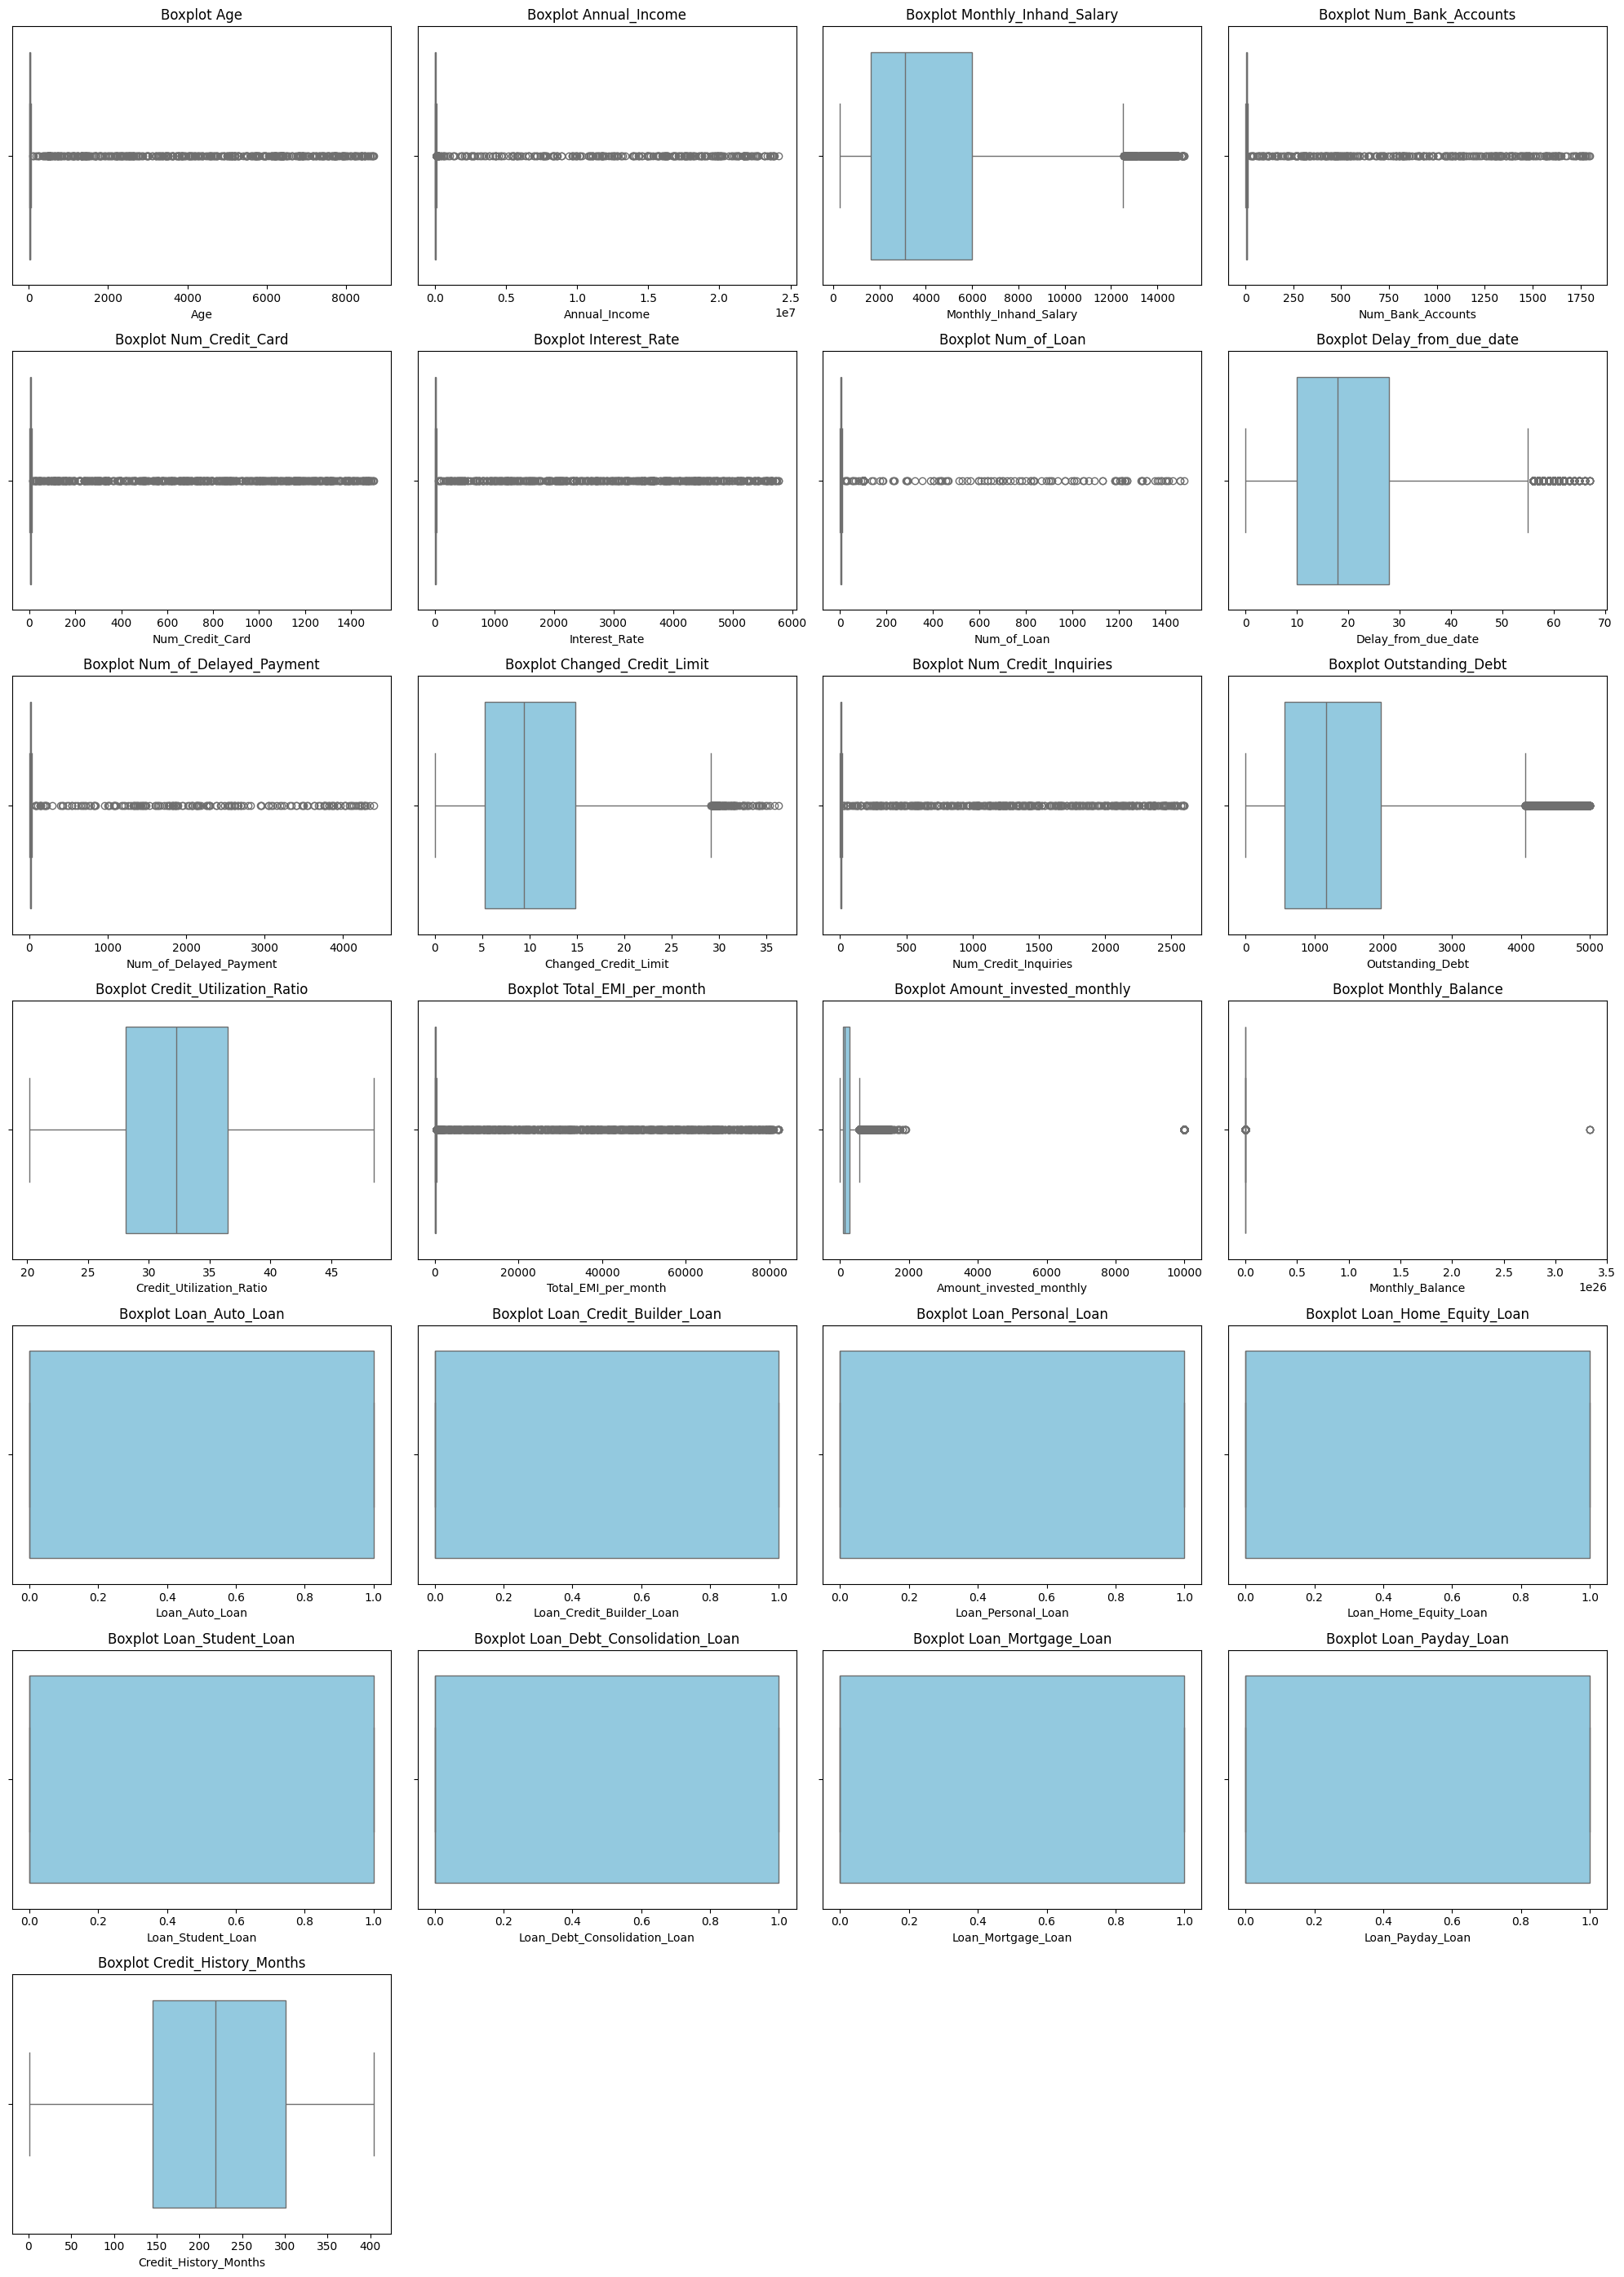

In [38]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

n_rows = (len(num_cols) // 4) + 1
plt.figure(figsize=(20, n_rows * 4))
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, 4, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.tight_layout()

plt.show()

Boxplot ini dibuat sebelum outlier capping dilakukan, dan hasilnya menunjukkan betapa parahnya outlier di dataset ini. Annual_Income, Num_Bank_Accounts, Interest_Rate, dan Monthly_Balance punya whisker yang sangat panjang ke kanan, artinya ada nilai-nilai ekstrem yang jauh sekali dari distribusi normal. Monthly_Balance bahkan sampai skala 3.5×10²⁶ yang jelas merupakan data anomaly.

C:\Users\andro\AppData\Local\Temp\ipykernel_15348\37807565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_Score', data=df, palette='viridis')


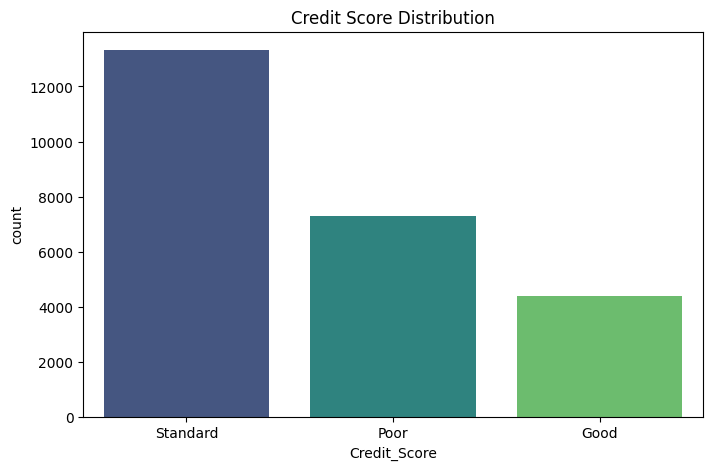

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Credit_Score', data=df, palette='viridis')
plt.title('Credit Score Distribution')
plt.show()

Dataset ini tidak seimbang: kelas Standard mendominasi dengan sekitar 13.300 data, diikuti Poor sekitar 7.300, dan Good paling sedikit hanya sekitar 4.400. Ketidakseimbangan ini yang jadi alasan kenapa dipakai class_weight='balanced' di beberapa model dan macro F1 sebagai metrik evaluasi.

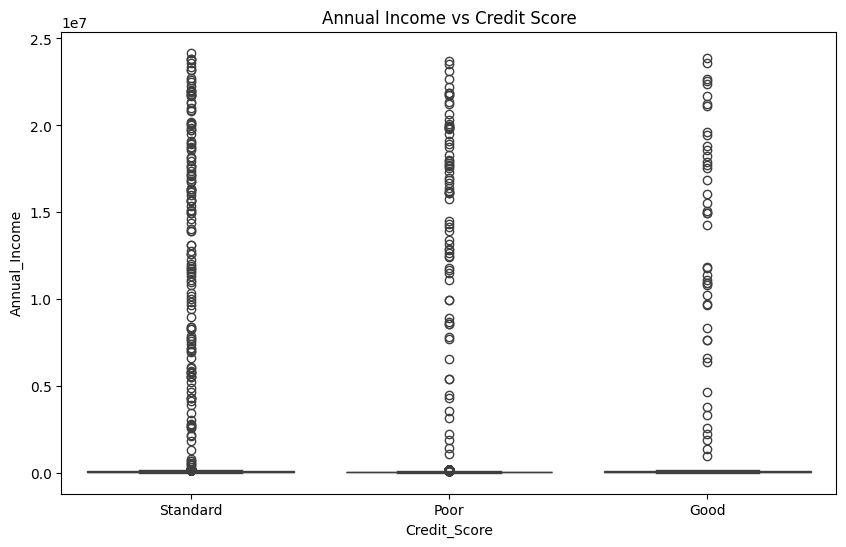

In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Credit_Score', y='Annual_Income', data=df)
plt.title('Annual Income vs Credit Score')
plt.show()

Plot ini dibuat sebelum outlier capping, makanya sumbu Y-nya sampai 2.5×10⁷. Terlihat outlier Annual_Income tersebar merata di ketiga kelas (Standard, Poor, Good), artinya income ekstrem tidak spesifik ke satu kelas saja. Secara keseluruhan, Annual_Income tidak memberikan pemisahan yang jelas antar kelas kredit.

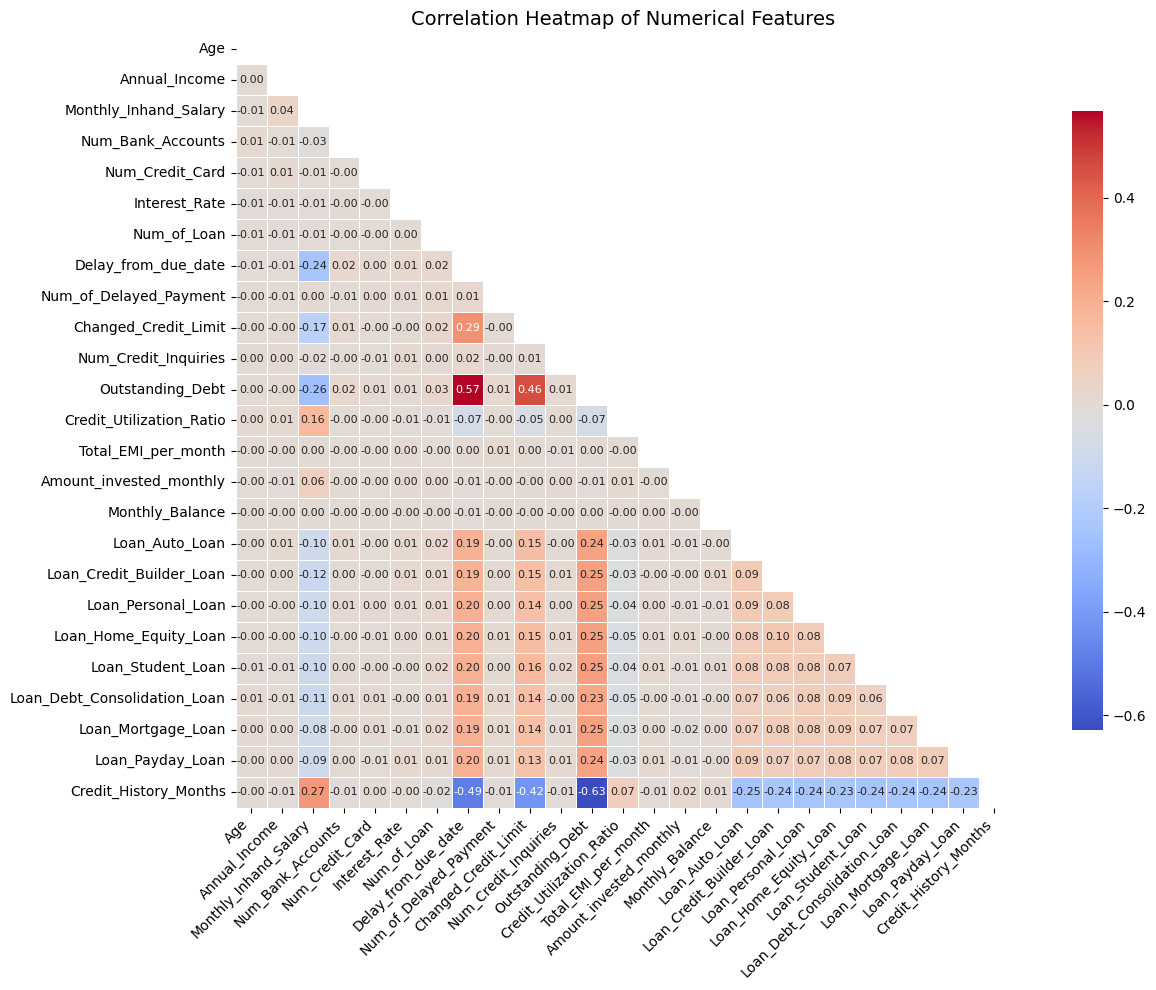

In [41]:
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()


Sebagian besar fitur punya korelasi yang sangat rendah satu sama lain. Yang paling menonjol: Outstanding_Debt berkorelasi cukup kuat dengan Num_of_Delayed_Payment (0.57) dan Changed_Credit_Limit (0.46), dan Credit_History_Months punya korelasi negatif cukup kuat dengan Outstanding_Debt (-0.63) dan Delay_from_due_date (-0.49), yang masuk akal karena makin lama riwayat kredit biasanya makin disiplin.

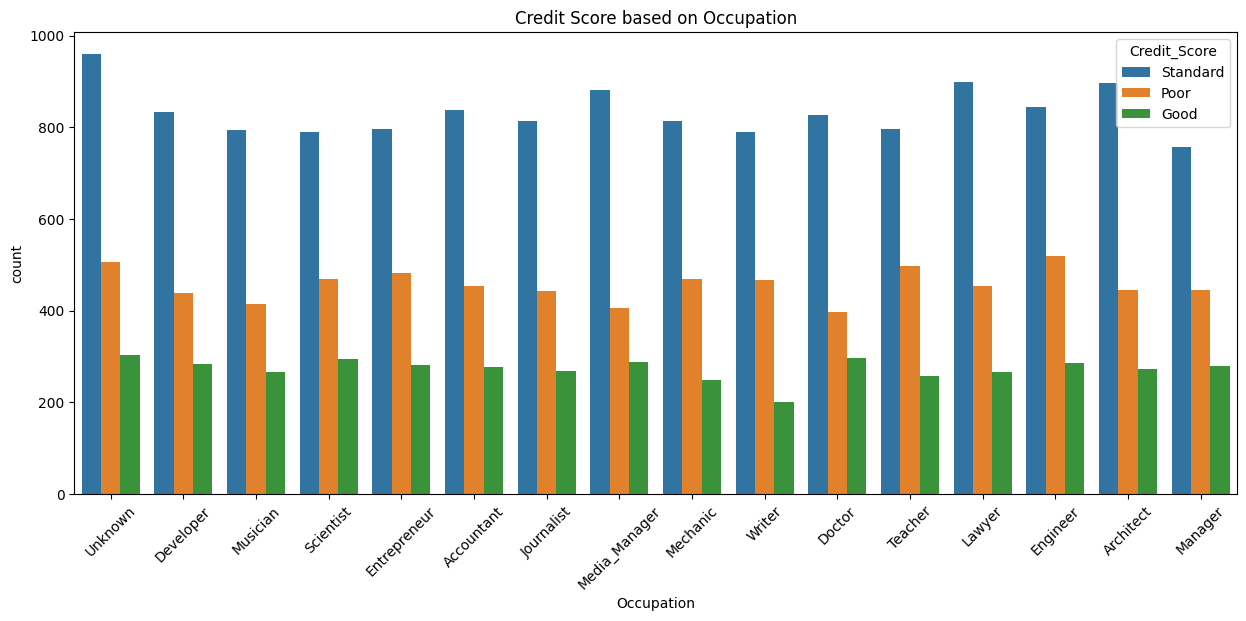

In [42]:
plt.figure(figsize=(15, 6))
sns.countplot(x='Occupation', hue='Credit_Score', data=df)
plt.xticks(rotation=45)
plt.title('Credit Score based on Occupation')
plt.show()

Pola distribusi kredit hampir identik di semua jenis pekerjaan: Standard selalu paling tinggi, diikuti Poor, lalu Good. Tidak ada satu pun pekerjaan yang punya profil kredit signifikan berbeda dari yang lain, yang mengindikasikan Occupation bukan fitur yang terlalu diskriminatif untuk prediksi.

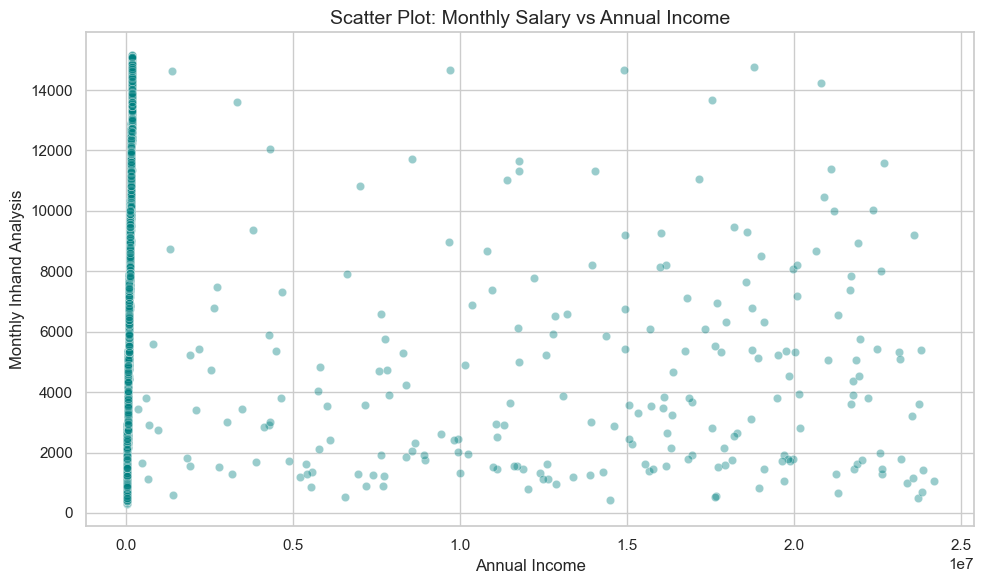

In [43]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Annual_Income'], 
    y = df['Monthly_Inhand_Salary'],
    alpha=0.4, 
    color='teal'
)

plt.title('Scatter Plot: Monthly Salary vs Annual Income', fontsize=14)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Monthly Inhand Analysis', fontsize=12)

plt.tight_layout()
plt.show()


Plot ini masih menggunakan data sebelum capping, dan hasilnya mayoritas titik menumpuk di sisi kiri (Annual Income mendekati 0) karena outlier yang sangat ekstrem merentangkan sumbu X hingga 2.5×10⁷. Seharusnya Monthly Salary dan Annual Income berkorelasi positif, tapi pola itu tidak terlihat jelas karena distorsi outlier.

In [44]:
## Anomaly Check - Distribusi Percentile P95 hingga P99
 
suspect_cols = [
    'Annual_Income',
    'Monthly_Balance',
    'Num_Bank_Accounts',
    'Num_Credit_Card', 
    'Interest_Rate',
    'Num_of_Loan',
    'Num_Credit_Inquiries',
    'Num_of_Delayed_Payment',
    'Total_EMI_per_month',
    'Age'
]
 
# Header
print(f"{'Kolom':<30} {'P95':>12} {'P96':>12} {'P97':>12} {'P98':>12} {'P99':>12} {'Max':>15} {'> P99':>8} {'% Total':>8}")
print("-" * 125)
 
for col in suspect_cols:
    p95 = df[col].quantile(0.95)
    p96 = df[col].quantile(0.96)
    p97 = df[col].quantile(0.97)
    p98 = df[col].quantile(0.98)
    p99 = df[col].quantile(0.99)
    max_val = df[col].max()
    count_above = (df[col] > p99).sum()
    pct = count_above / len(df) * 100
    print(f"{col:<30} {p95:>12,.2f} {p96:>12,.2f} {p97:>12,.2f} {p98:>12,.2f} {p99:>12,.2f} {max_val:>15,.2f} {count_above:>8} {pct:>7.2f}%")

Kolom                                   P95          P96          P97          P98          P99             Max    > P99  % Total
-----------------------------------------------------------------------------------------------------------------------------
Annual_Income                    134,928.36   142,170.43   150,625.48   167,258.04 1,895,719.48   24,188,807.00      250    1.00%
Monthly_Balance                      862.31       911.40       963.66     1,032.64     1,129.28 333,333,333,333,333,314,856,026,112.00      248    0.99%
Num_Bank_Accounts                     10.00        10.00        10.00        10.00       442.05        1,798.00      250    1.00%
Num_Credit_Card                       10.00        10.00        10.00       147.00       824.01        1,499.00      250    1.00%
Interest_Rate                         32.00        33.00        34.00        34.00     2,889.07        5,775.00      250    1.00%
Num_of_Loan                            9.00       100.00       100.00  

In [45]:
caps = {
    'Annual_Income'         : df['Annual_Income'].quantile(0.98),         # 167k
    'Num_Bank_Accounts'     : df['Num_Bank_Accounts'].quantile(0.98),     # 10
    'Num_Credit_Card'       : df['Num_Credit_Card'].quantile(0.95),       # 10
    'Interest_Rate'         : df['Interest_Rate'].quantile(0.95),         # 32%
    'Num_of_Loan'           : df['Num_of_Loan'].quantile(0.95),           # 9
    'Num_Credit_Inquiries'  : df['Num_Credit_Inquiries'].quantile(0.98),  # 16
    'Num_of_Delayed_Payment': df['Num_of_Delayed_Payment'].quantile(0.99),# 27 (ok)
    'Total_EMI_per_month'   : df['Total_EMI_per_month'].quantile(0.95),   # 446
     'Monthly_Balance'       : df['Monthly_Balance'].quantile(0.99),
     'Age' : df['Age'].quantile(0.95) 
}

for col, cap_val in caps.items():
    df.loc[df[col] > cap_val, col] = cap_val

In [46]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,...,Monthly_Balance,Loan_Auto_Loan,Loan_Credit_Builder_Loan,Loan_Personal_Loan,Loan_Home_Equity_Loan,Loan_Student_Loan,Loan_Debt_Consolidation_Loan,Loan_Mortgage_Loan,Loan_Payday_Loan,Credit_History_Months
count,25000.000000,25000.000000,21417.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,23267.000000,24482.000000,...,24711.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,22751.000000
mean,33.769160,51810.998483,4215.671131,5.437920,5.637600,14.87356,3.798480,21.221760,13.485065,10.454362,...,400.799667,0.305400,0.31952,0.315040,0.316200,0.309880,0.30992,0.321320,0.318520,220.614786
std,11.131061,39766.410523,3187.623134,2.621988,2.155971,8.89979,2.646626,14.844798,6.335072,6.654462,...,208.508995,0.460586,0.46630,0.464541,0.465001,0.462453,0.46247,0.466993,0.465912,99.335388
min,14.000000,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.010000,...,0.899335,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000
25%,25.000000,19559.450000,1634.720833,4.000000,4.000000,8.00000,2.000000,10.000000,9.000000,5.310000,...,270.262177,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,145.000000
50%,33.000000,37813.630000,3111.437500,6.000000,5.000000,13.00000,3.000000,18.000000,14.000000,9.440000,...,336.848620,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,219.000000
75%,42.000000,73096.780000,5986.647500,7.000000,7.000000,20.00000,6.000000,28.000000,18.000000,14.827500,...,469.280320,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,301.000000
max,54.000000,167258.040000,15167.180000,10.000000,10.000000,32.00000,9.000000,67.000000,27.000000,36.290000,...,1129.277659,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,404.000000


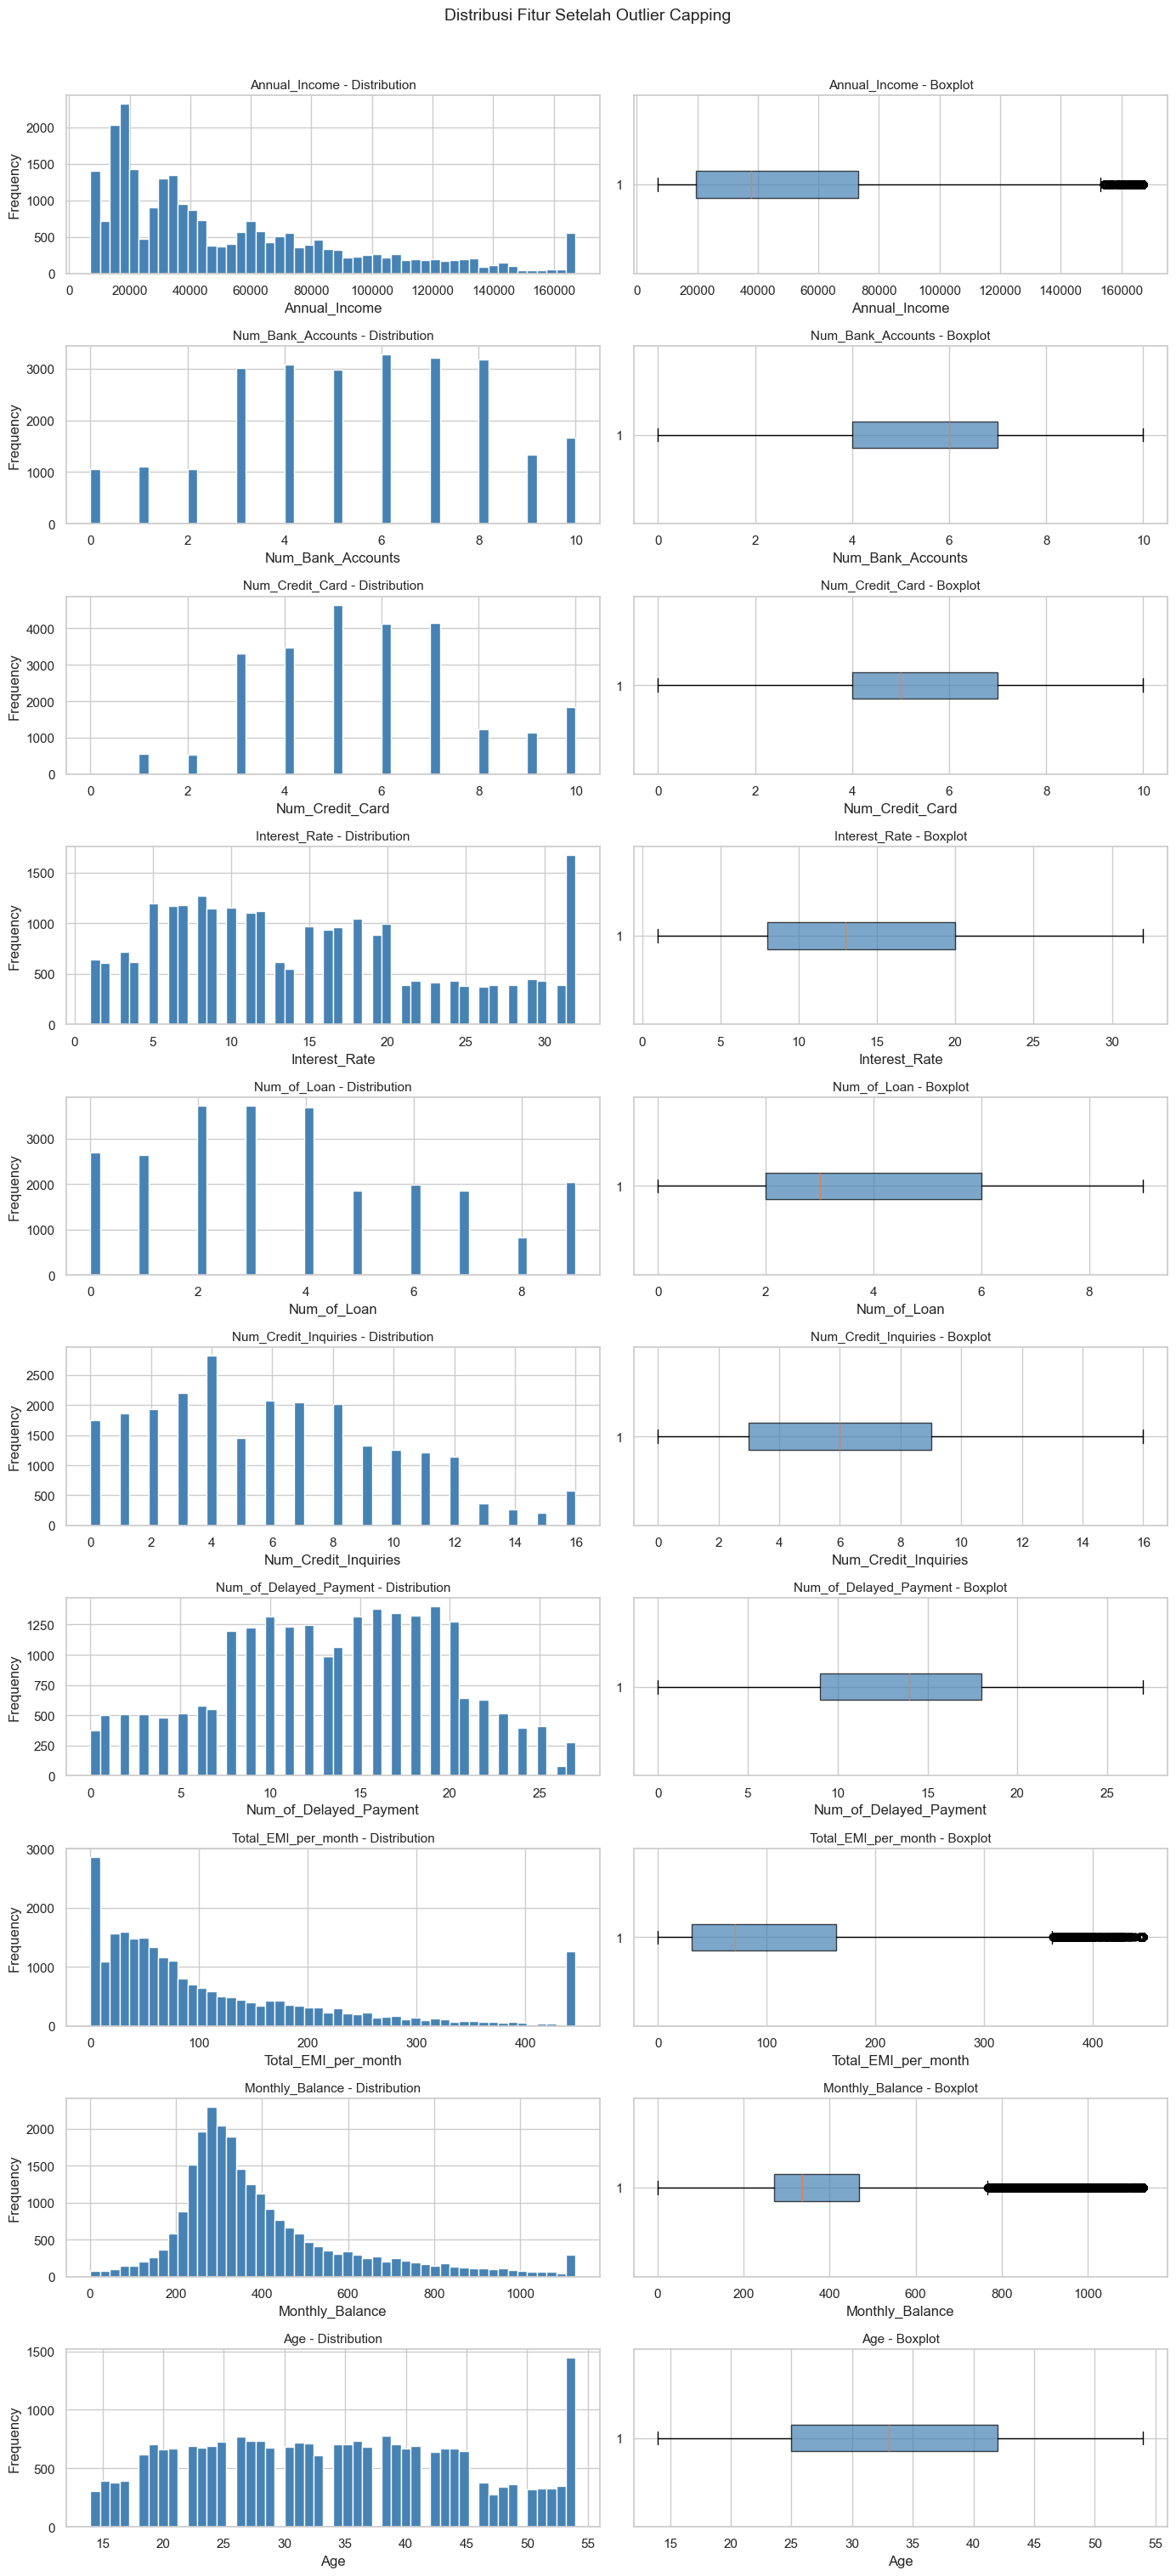

In [47]:
cap_cols = list(caps.keys())
 
fig, axes = plt.subplots(len(cap_cols), 2, figsize=(14, len(cap_cols) * 3))
 
for i, col in enumerate(cap_cols):
    data = df[col].dropna()
    
    # Histogram
    axes[i, 0].hist(data, bins=50, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} - Distribution', fontsize=11)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
 
    # Boxplot
    axes[i, 1].boxplot(data, vert=False, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i, 1].set_title(f'{col} - Boxplot', fontsize=11)
    axes[i, 1].set_xlabel(col)
 
plt.suptitle('Distribusi Fitur Setelah Outlier Capping', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Setelah capping, 8 kolom yang ditangani terlihat jauh lebih bersih. Annual_Income sekarang terpotong di sekitar 167 ribu, Num_Bank_Accounts di 10, Interest_Rate di 32%. Total_EMI_per_month masih punya ekor kanan yang panjang tapi sudah jauh lebih terkontrol dibanding sebelumnya.


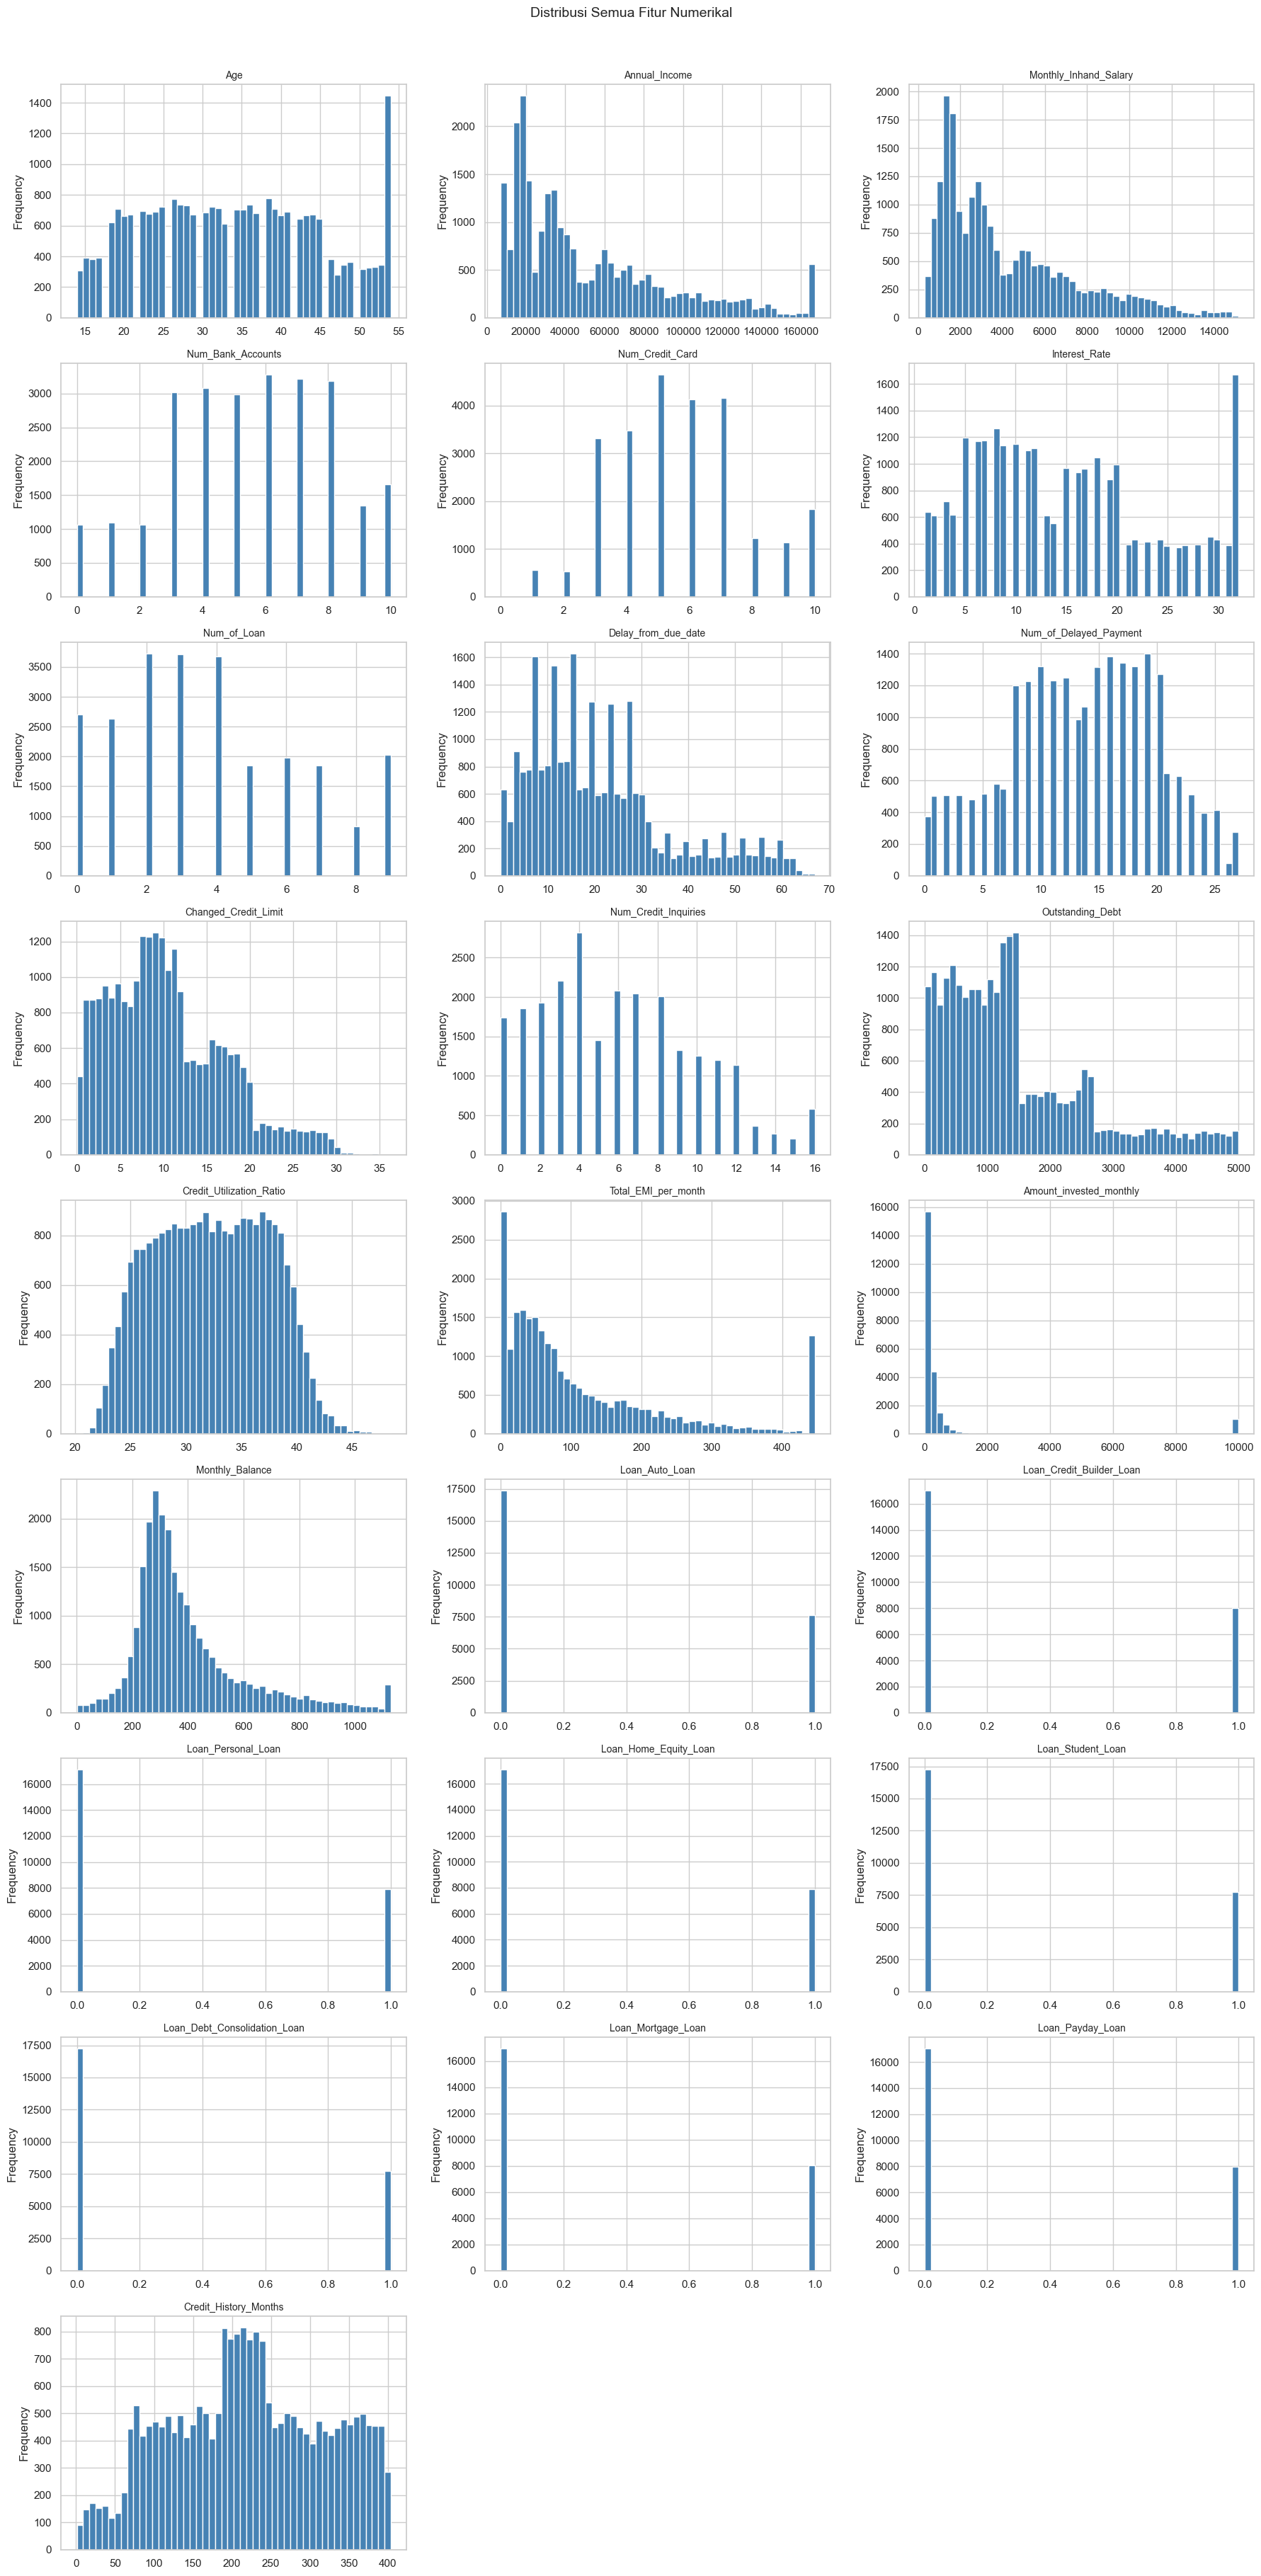

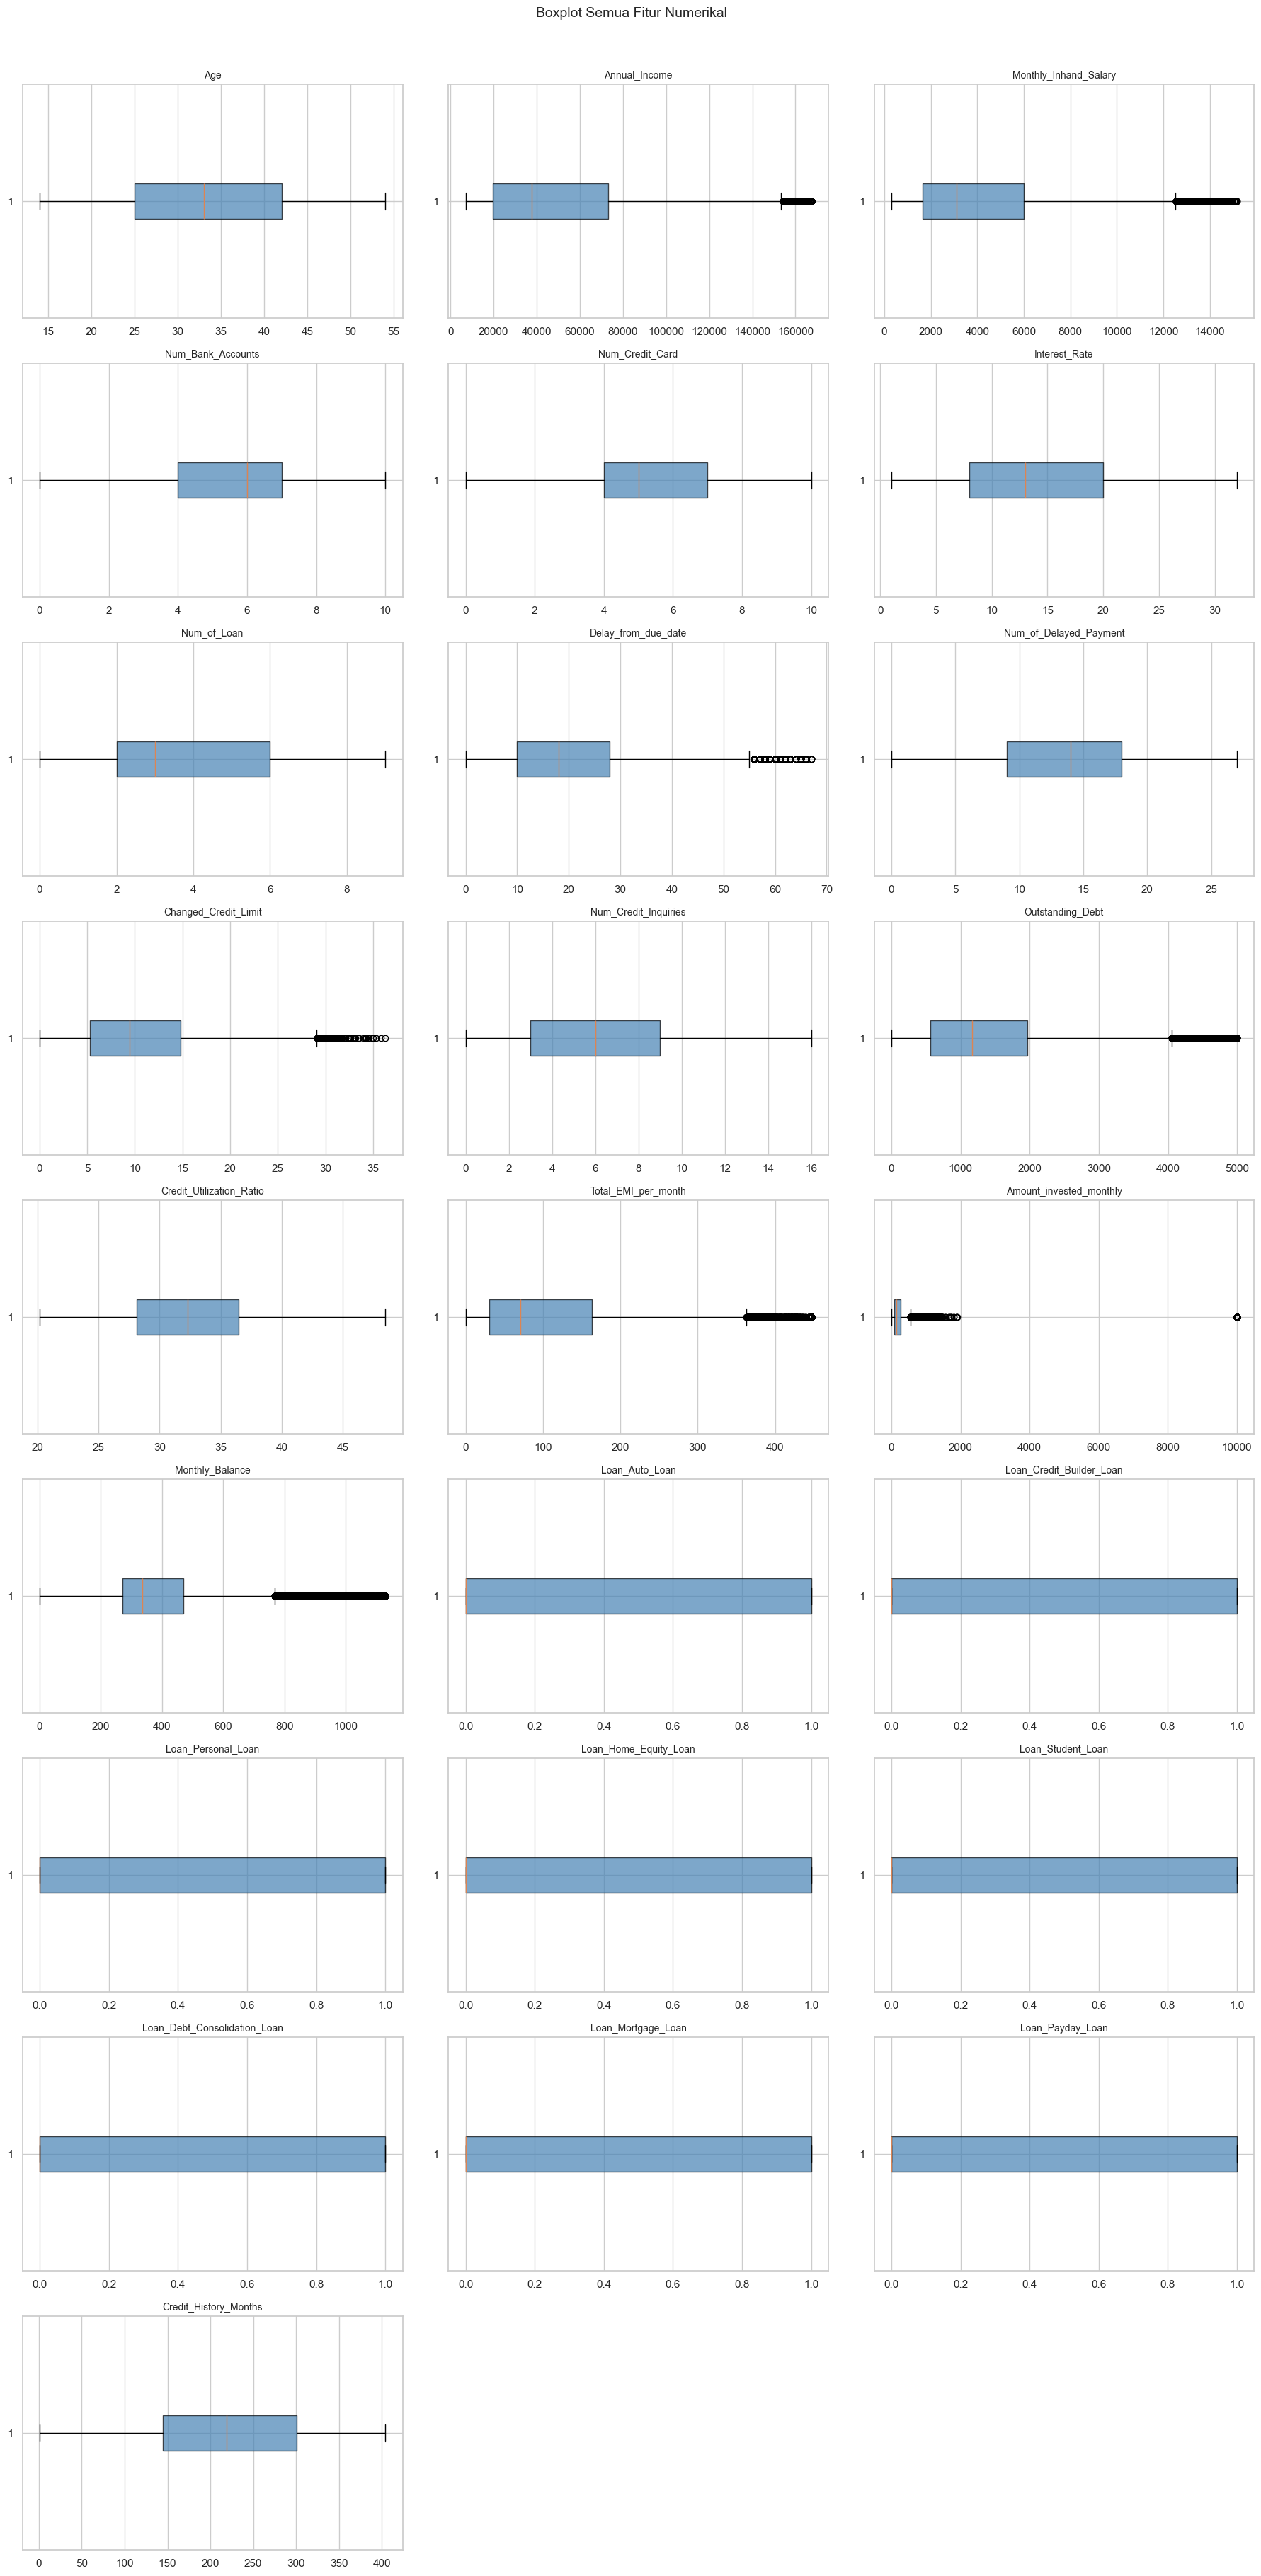

In [48]:
## Distribusi & Boxplot Semua Kolom Numerikal

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

# --- Histogram ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Semua Fitur Numerikal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# --- Boxplot ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot Semua Fitur Numerikal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Histogram semua 27 fitur setelah cleaning selesai. Fitur seperti Age dan Credit_History_Months punya distribusi yang cukup normal, sedangkan Annual_Income dan Monthly_Inhand_Salary masih right-skewed. Kolom-kolom Loan binary hanya punya dua bar (0 dan 1)

Boxplot final setelah seluruh proses cleaning. Sebagian besar kolom sudah bersih dan box-nya terlihat jelas.

## Splitting

In [49]:
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

In [50]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_)  

Classes: ['Good' 'Poor' 'Standard']


In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

Data dibagi menjadi fitur (X) dan target (y) dengan 3 kelas: Good, Poor, Standard. Split dilakukan 80:20 dengan stratify agar proporsi tiap kelas seimbang di train dan test set menghasilkan 874 Good, 1.460 Poor, dan 2.666 Standard di test set.

## Encoding and Scaling


In [52]:
num_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
loan_cols = [c for c in X.columns if c.startswith('Loan_')]

In [53]:
num_cols = [c for c in num_cols if c not in loan_cols]

In [54]:
print(f"Num  ({len(num_cols)}): {num_cols}")
print(f"Cat  ({len(cat_cols)}): {cat_cols}")
print(f"Loan ({len(loan_cols)}): {loan_cols}")

Num  (17): ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Months']
Cat  (5): ['Month', 'Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
Loan (8): ['Loan_Auto_Loan', 'Loan_Credit_Builder_Loan', 'Loan_Personal_Loan', 'Loan_Home_Equity_Loan', 'Loan_Student_Loan', 'Loan_Debt_Consolidation_Loan', 'Loan_Mortgage_Loan', 'Loan_Payday_Loan']


In [ ]:
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

In [56]:
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [57]:
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols),
], remainder='passthrough')

17 fitur numerik diimputasi dengan median lalu di-scale dengan RobustScaler (tahan outlier). 5 fitur kategorik diimputasi dengan "Unknown" lalu di-encode dengan OrdinalEncoder. 8 fitur loan binary dibiarkan apa adanya lewat remainder='passthrough'.

## Modelling

In [58]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        random_state=42
    )
    
}


Empat model diuji baseline tanpa tuning: Random Forest (F1: 0.7142), LightGBM (0.7000), XGBoost (0.6993), dan MLP (0.5983). Random Forest langsung unggul di baseline, sedangkan MLP paling rendah karena data tabular memang bukan kekuatan neural network.

In [59]:
results = {}

In [60]:
for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipe.fit(X_train, y_train)        
    y_pred = pipe.predict(X_test)       
    f1 = f1_score(y_test, y_pred, average='macro')  

    results[name] = {
        'pipeline': pipe,
        'y_pred': y_pred,
        'f1_macro': f1
    }

    print(f"\n{'='*55}")
    print(f"Model    : {name}")
    print(f"Macro F1 : {f1:.4f}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : Random Forest
Macro F1 : 0.7176
              precision    recall  f1-score   support

        Good       0.67      0.59      0.63       874
        Poor       0.77      0.72      0.74      1460
    Standard       0.75      0.81      0.78      2666

    accuracy                           0.75      5000
   macro avg       0.73      0.71      0.72      5000
weighted avg       0.74      0.75      0.74      5000


Model    : XGBoost
Macro F1 : 0.6992
              precision    recall  f1-score   support

        Good       0.63      0.61      0.62       874
        Poor       0.74      0.69      0.71      1460
    Standard       0.75      0.78      0.76      2666

    accuracy                           0.72      5000
   macro avg       0.70      0.69      0.70      5000
weighted avg       0.72      0.72      0.72      5000



c:\Users\andro\anaconda3\envs\model_deployment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Model    : LightGBM
Macro F1 : 0.6981
              precision    recall  f1-score   support

        Good       0.54      0.80      0.64       874
        Poor       0.70      0.78      0.73      1460
    Standard       0.82      0.64      0.72      2666

    accuracy                           0.71      5000
   macro avg       0.68      0.74      0.70      5000
weighted avg       0.74      0.71      0.71      5000


Model    : MLP
Macro F1 : 0.5983
              precision    recall  f1-score   support

        Good       0.51      0.49      0.50       874
        Poor       0.62      0.61      0.61      1460
    Standard       0.68      0.69      0.68      2666

    accuracy                           0.63      5000
   macro avg       0.60      0.60      0.60      5000
weighted avg       0.63      0.63      0.63      5000



Dari keempat model yang diuji, Random Forest memberikan performa terbaik dengan macro F1 0.72 dan accuracy 75%, yang artinya model ini paling konsisten dalam mengklasifikasikan ketiga kelas credit score secara merata bukan hanya pintar di satu kelas saja. Kelas Good memang jadi tantangan di semua model karena jumlah datanya paling sedikit dibanding Poor dan Standard, sehingga model cenderung kurang sensitif mengenalinya. MLP jadi yang paling rendah karena arsitektur neural network sederhana seperti ini butuh data jauh lebih banyak untuk bisa belajar pola yang kompleks, sedangkan tree-based model seperti Random Forest dan XGBoost lebih cocok untuk dataset tabular berukuran sedang seperti ini.

# Hyperparameter Tuning

In [61]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

Keempat model di-tune dengan RandomizedSearchCV dengan  20 kombinasi parameter acak, 3-fold CV, scoring macro F1. Proses ini cukup berat tapi hasilnya semua model naik, khususnya MLP yang loncat dari 0.5983 ke 0.6658.

## Random Forest - RandomizedSearchCV

In [62]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [None, 10, 20, 30, 40, 50],
    'classifier__min_samples_split': [2, 5, 10, 15],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
}

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
y_pred = best_rf.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

results['Random Forest (Tuned)'] = {
    'pipeline': best_rf,
    'y_pred': y_pred,
    'f1_macro': f1
}

print(f"\n{'='*55}")
print(f"Model    : Random Forest (Tuned)")
print(f"Best Params: {rf_search.best_params_}")
print(f"Macro F1 : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : Random Forest (Tuned)
Best Params: {'classifier__n_estimators': 500, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 50}
Macro F1 : 0.7148
              precision    recall  f1-score   support

        Good       0.56      0.74      0.64       874
        Poor       0.74      0.76      0.75      1460
    Standard       0.81      0.71      0.76      2666

    accuracy                           0.73      5000
   macro avg       0.70      0.74      0.71      5000
weighted avg       0.74      0.73      0.73      5000



Random Forest setelah di-tuning dengan RandomizedSearchCV menemukan parameter terbaik: 500 trees, max_depth 50, min_samples_split 10, dan min_samples_leaf 1. Hasilnya macro F1 0.7148 yang sedikit lebih rendah dari versi untuned (0.7176), artinya dalam kasus ini hyperparameter tuning tidak memberikan peningkatan signifikan, kemungkinan karena default Random Forest sudah cukup optimal untuk dataset ini. Kelas Good tetap paling sulit dengan F1 0.64, konsisten dengan semua model lain karena memang jumlah sampelnya paling sedikit.

## XGBoost - RandomizedSearchCV

In [63]:
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__max_depth': [3, 4, 5, 6, 7, 8],
    'classifier__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
}

xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1))
])

xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_
y_pred = best_xgb.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

results['XGBoost (Tuned)'] = {
    'pipeline': best_xgb,
    'y_pred': y_pred,
    'f1_macro': f1
}

print(f"\n{'='*55}")
print(f"Model    : XGBoost (Tuned)")
print(f"Best Params: {xgb_search.best_params_}")
print(f"Macro F1 : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : XGBoost (Tuned)
Best Params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.7}
Macro F1 : 0.7122
              precision    recall  f1-score   support

        Good       0.66      0.61      0.64       874
        Poor       0.75      0.71      0.73      1460
    Standard       0.75      0.79      0.77      2666

    accuracy                           0.74      5000
   macro avg       0.72      0.70      0.71      5000
weighted avg       0.74      0.74      0.74      5000



XGBoost setelah tuning menemukan parameter terbaik: learning_rate 0.2, max_depth 8, subsample 0.8, colsample_bytree 0.7, dan 200 trees. Macro F1 naik dari 0.6992 ke 0.7122, jadi tuning di sini memang memberikan peningkatan nyata berbeda dengan Random Forest yang justru sedikit turun setelah di-tuning. Tapi hasilnya masih di bawah Random Forest untuned (0.7176), dan kelas Good tetap paling sulit di F1 0.64 karena masalah imbalance-nya memang bukan sesuatu yang bisa diselesaikan hanya dengan hyperparameter tuning.

## LightGBM - RandomizedSearchCV

In [64]:
lgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'classifier__max_depth': [3, 4, 5, 6, 7, -1],
    'classifier__num_leaves': [15, 31, 50, 70, 100],
    'classifier__min_child_samples': [5, 10, 20, 30, 50],
}

lgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1))
])

lgb_search = RandomizedSearchCV(
    lgb_pipe,
    param_distributions=lgb_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

lgb_search.fit(X_train, y_train)

best_lgb = lgb_search.best_estimator_
y_pred = best_lgb.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

results['LightGBM (Tuned)'] = {
    'pipeline': best_lgb,
    'y_pred': y_pred,
    'f1_macro': f1
}

print(f"\n{'='*55}")
print(f"Model    : LightGBM (Tuned)")
print(f"Best Params: {lgb_search.best_params_}")
print(f"Macro F1 : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : LightGBM (Tuned)
Best Params: {'classifier__num_leaves': 100, 'classifier__n_estimators': 400, 'classifier__min_child_samples': 10, 'classifier__max_depth': -1, 'classifier__learning_rate': 0.1}
Macro F1 : 0.7247
              precision    recall  f1-score   support

        Good       0.63      0.68      0.65       874
        Poor       0.75      0.76      0.75      1460
    Standard       0.78      0.76      0.77      2666

    accuracy                           0.74      5000
   macro avg       0.72      0.73      0.72      5000
weighted avg       0.75      0.74      0.74      5000



c:\Users\andro\anaconda3\envs\model_deployment\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM setelah tuning menemukan parameter terbaik: 400 estimators, num_leaves 100, max_depth -1 (tidak dibatasi), dan learning_rate 0.1. Macro F1 naik dari 0.6981 ke 0.7247 — ini yang tertinggi dari seluruh model yang diuji, mengalahkan Random Forest untuned (0.7176) maupun semua versi tuned lainnya. Yang menarik, max_depth -1 artinya tree dibiarkan tumbuh bebas tanpa batas kedalaman, dan justru di situ LightGBM menemukan sweet spot-nya berkat mekanisme leaf-wise growth yang lebih efisien dibanding depth-wise seperti XGBoost.

## MLP Classifier - RandomizedSearchCV

In [65]:
mlp_param_grid = {
    'classifier__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate_init': [0.001, 0.01, 0.05, 0.1],
}

mlp_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(max_iter=300, random_state=42))
])

mlp_search = RandomizedSearchCV(
    mlp_pipe,
    param_distributions=mlp_param_grid,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

mlp_search.fit(X_train, y_train)

best_mlp = mlp_search.best_estimator_
y_pred = best_mlp.predict(X_test)
f1 = f1_score(y_test, y_pred, average='macro')

results['MLP'] = {
    'pipeline': best_mlp,
    'y_pred': y_pred,
    'f1_macro': f1
}

print(f"\n{'='*55}")
print(f"Model    : MLP")
print(f"Best Params: {mlp_search.best_params_}")
print(f"Macro F1 : {f1:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Model    : MLP
Best Params: {'classifier__learning_rate_init': 0.01, 'classifier__hidden_layer_sizes': (50,), 'classifier__alpha': 0.1, 'classifier__activation': 'tanh'}
Macro F1 : 0.6662
              precision    recall  f1-score   support

        Good       0.55      0.61      0.58       874
        Poor       0.71      0.65      0.68      1460
    Standard       0.74      0.74      0.74      2666

    accuracy                           0.69      5000
   macro avg       0.67      0.67      0.67      5000
weighted avg       0.70      0.69      0.69      5000



MLP setelah tuning menemukan parameter terbaik: arsitektur yang simpel dengan 1 hidden layer berisi 50 neuron, aktivasi tanh, alpha 0.1, dan learning_rate 0.01. Macro F1 naik dari 0.5983 ke 0.6662 peningkatan sekitar 0.068 yang sebenarnya paling besar secara proporsional dibanding model lain, artinya MLP paling banyak diuntungkan oleh tuning. Tapi meski lonjakannya paling besar, hasilnya tetap yang paling rendah dari semua model karena neural network sederhana seperti ini memang punya ceiling yang lebih rendah untuk dataset tabular berukuran sedang dibanding tree-based model.

## Results Summary (All Models)

In [72]:
sorted_results = sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True)

print("=== Ranked by F1 Macro and Accuracy ===")
for name, res in sorted_results:
    acc = accuracy_score(y_test, res['y_pred'])
    print(f"{name:<25} f1_macro = {res['f1_macro']:.4f}   accuracy = {acc:.4f}")

print("\n=== Before vs After Tuning ===")
pairs = [
    ("Random Forest", "Random Forest (Tuned)"),
    ("XGBoost",       "XGBoost (Tuned)"),
    ("LightGBM",      "LightGBM (Tuned)"),
    ("MLP",           "MLP (Tuned)"),
]
for base, tuned in pairs:
    if base not in results or tuned not in results:
        continue
    f1_before  = results[base]['f1_macro']
    f1_after   = results[tuned]['f1_macro']
    acc_before = accuracy_score(y_test, results[base]['y_pred'])
    acc_after  = accuracy_score(y_test, results[tuned]['y_pred'])
    delta_f1   = f1_after - f1_before
    delta_acc  = acc_after - acc_before
    print(f"{base:<15} f1: {f1_before:.4f} -> {f1_after:.4f} ({delta_f1:+.4f})   acc: {acc_before:.4f} -> {acc_after:.4f} ({delta_acc:+.4f})")

=== Ranked by F1 Macro and Accuracy ===
LightGBM (Tuned)          f1_macro = 0.7247   accuracy = 0.7432
Random Forest             f1_macro = 0.7176   accuracy = 0.7454
Random Forest (Tuned)     f1_macro = 0.7148   accuracy = 0.7308
XGBoost (Tuned)           f1_macro = 0.7122   accuracy = 0.7366
XGBoost                   f1_macro = 0.6992   accuracy = 0.7248
LightGBM                  f1_macro = 0.6981   accuracy = 0.7068
MLP                       f1_macro = 0.6662   accuracy = 0.6934

=== Before vs After Tuning ===
Random Forest   f1: 0.7176 -> 0.7148 (-0.0028)   acc: 0.7454 -> 0.7308 (-0.0146)
XGBoost         f1: 0.6992 -> 0.7122 (+0.0131)   acc: 0.7248 -> 0.7366 (+0.0118)
LightGBM        f1: 0.6981 -> 0.7247 (+0.0266)   acc: 0.7068 -> 0.7432 (+0.0364)


Dari 8 model yang diuji, LightGBM (Tuned) mencatat F1 macro tertinggi di 0.7247, diikuti Random Forest untuned (0.7176) dan XGBoost (Tuned) (0.7122). Tuning tidak selalu membantu karena Random Forest justru sedikit turun setelah di-tuning (0.7176 -> 0.7148), sementara LightGBM dan XGBoost naik cukup signifikan. Model yang disimpan sebagai model.pkl untuk deployment adalah LightGBM (Tuned) sebagai model dengan F1 macro terbaik.

##